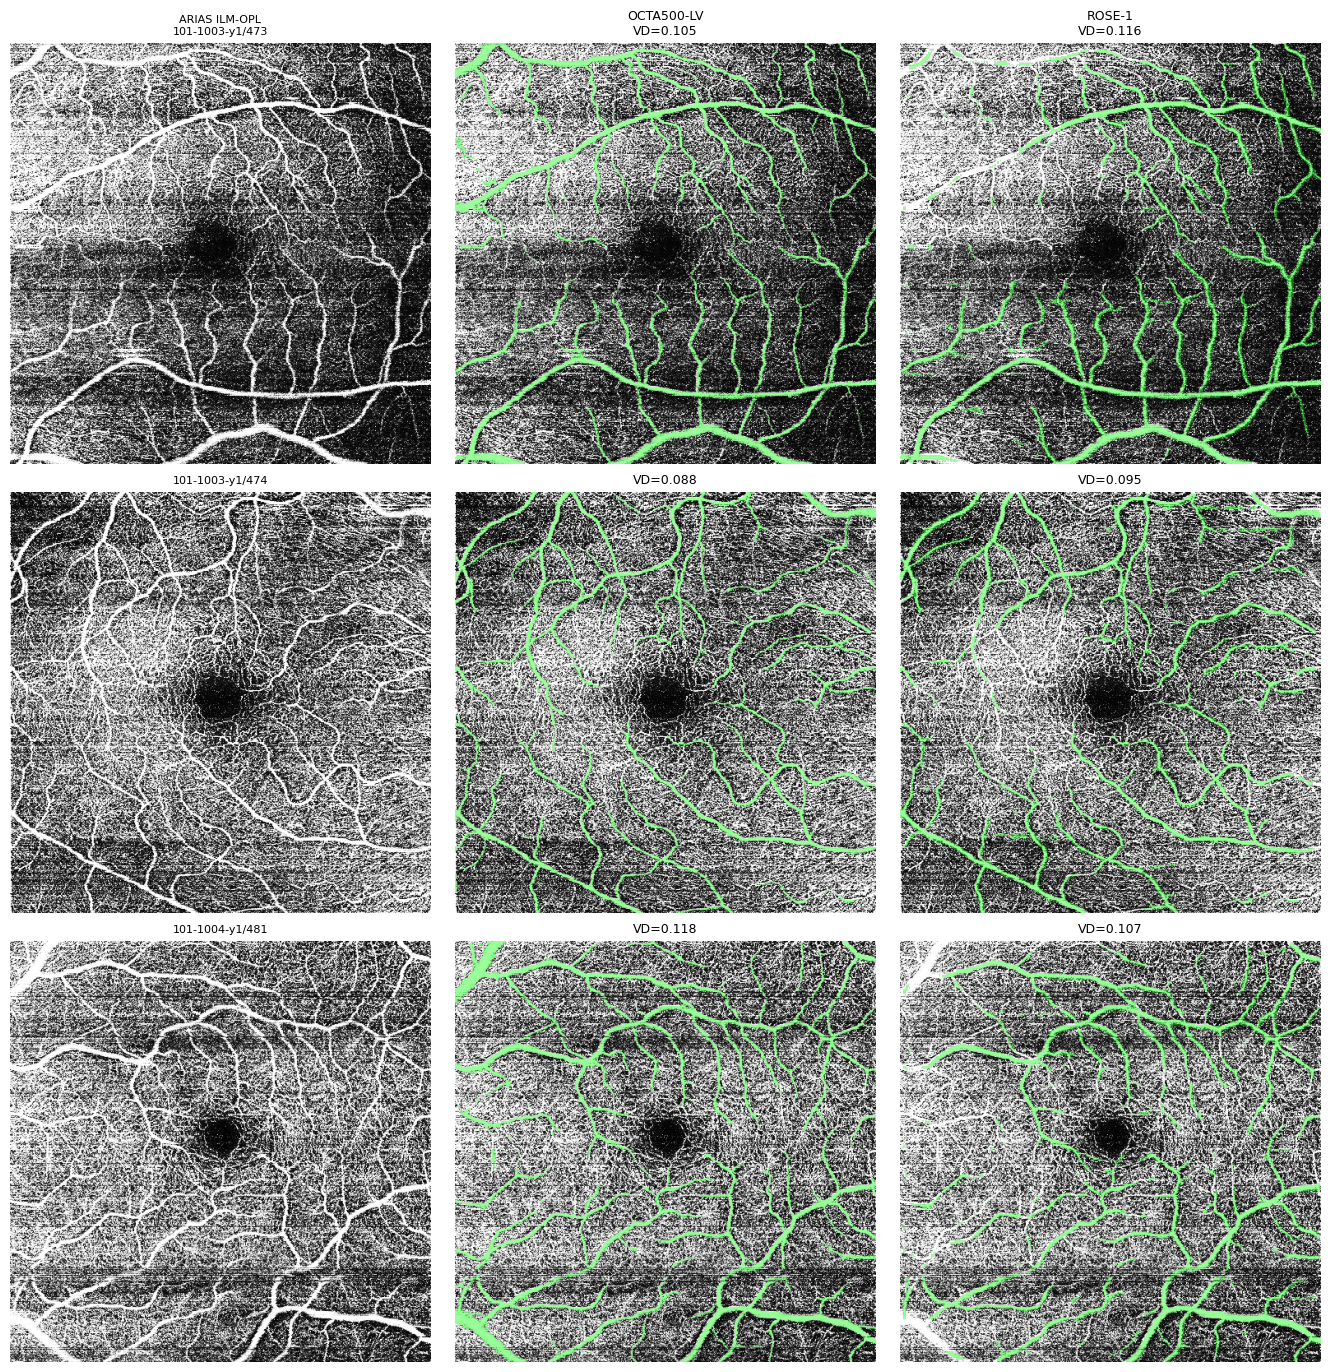

model            OCTA500-LV  ROSE-1
image                              
101-1003-y1/473       0.105   0.116
101-1003-y1/474       0.088   0.095
101-1004-y1/481       0.118   0.107


In [1]:
import sys; sys.path.append('/users/egottfri/code/octa-segmentation/src')
import h5py, numpy as np, cv2, torch, gc, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model import build_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ARIAS  = Path("/oscar/data/jlee123/procdata/adp/22-retina-arias-y1")
SLAB   = (2,3,4,5,6,7,8)
N_IMAGES = 3               # start small; raise once it's stable
THRESH   = 0.5

MODELS = {
    "OCTA500-LV": ("/users/egottfri/code/octa-segmentation/results/octa500_lv_ablation/res_unet", 400),
    "ROSE-1":     ("/users/egottfri/code/octa-segmentation/results/rose1_ablation/raw/res_unet",   304),
}

def load_one(ckpt_dir):
    p = sorted(Path(ckpt_dir).glob("best_model_fold*.pth"))[0]   # single fold, not ensemble
    ck = torch.load(p, map_location=DEVICE)
    m = build_model(ck['model_name'], **ck['model_kwargs']).to(DEVICE)
    m.load_state_dict(ck['state_dict']); m.eval()
    return m

LOADED = {name: (load_one(d), size) for name, (d, size) in MODELS.items()}

def project(h5path):
    """Read only the SLAB layers, not the whole 500MB volume."""
    with h5py.File(h5path, "r") as h:
        lyr = h["r1/lyr"][:]                 # uint8, ~130MB
        m = np.isin(lyr, SLAB)
        octa = h["octa"]                     # dataset handle, not loaded yet
        pr = np.full(lyr.shape[:2], -np.inf, np.float32)
        for z in range(lyr.shape[2]):        # stream depth-slice by depth-slice
            sl = octa[:, :, z]
            msk = m[:, :, z]
            pr = np.where(msk & (sl > pr), sl, pr)
    del lyr, m; gc.collect()
    pr = np.where(np.isfinite(pr), pr, 0)
    return (255*(pr-pr.min())/(pr.max()-pr.min()+1e-8)).astype(np.uint8)

@torch.no_grad()
def segment(proj_full, model, size):
    img = cv2.resize(proj_full, (size, size), interpolation=cv2.INTER_AREA)
    x = torch.from_numpy(img.astype(np.float32)/255.)[None,None].to(DEVICE)
    return torch.sigmoid(model(x))[0,0].cpu().numpy()

files = sorted(ARIAS.rglob("*-p1a.h5"))[:N_IMAGES]
ncols = 1 + len(LOADED)
fig, axes = plt.subplots(N_IMAGES, ncols, figsize=(4.5*ncols, 4.6*N_IMAGES))
if N_IMAGES == 1: axes = axes[None, :]
records = []

for r, f in enumerate(files):
    stem = f"{f.parent.name}/{f.stem.replace('-p1a','')}"
    proj_full = project(f)
    axes[r,0].imshow(proj_full, cmap="gray"); axes[r,0].axis("off")
    axes[r,0].set_title(("ARIAS ILM-OPL\n" if r==0 else "") + stem, fontsize=8)
    for c, (name, (model, size)) in enumerate(LOADED.items(), start=1):
        prob = segment(proj_full, model, size)
        mask = cv2.resize((prob>THRESH).astype(np.uint8), proj_full.shape[::-1],
                          interpolation=cv2.INTER_NEAREST)
        vd = float((prob>THRESH).mean())
        records.append({"image":stem, "model":name, "vessel_density":round(vd,3)})
        axes[r,c].imshow(proj_full, cmap="gray")
        ov = np.zeros((*proj_full.shape,4)); ov[mask==1]=[0,1,0,0.4]; axes[r,c].imshow(ov)
        axes[r,c].axis("off")
        axes[r,c].set_title((f"{name}\n" if r==0 else "") + f"VD={vd:.3f}", fontsize=9)
    del proj_full; gc.collect()

plt.tight_layout(); plt.show()
print(pd.DataFrame(records).pivot(index="image", columns="model", values="vessel_density"))

In [5]:
from pathlib import Path
capdir = Path("/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary")
for p in sorted(capdir.rglob("*.pth")):
    print(p)

/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold1.pth
/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold2.pth
/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold3.pth
/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold4.pth
/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold5.pth


In [6]:
import torch
ck = torch.load("/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold1.pth",
                map_location="cpu")
print(type(ck))
if isinstance(ck, dict):
    print("keys:", list(ck.keys())[:8])

<class 'collections.OrderedDict'>
keys: ['enc1.double_conv.0.weight', 'enc1.double_conv.1.weight', 'enc1.double_conv.1.bias', 'enc1.double_conv.1.running_mean', 'enc1.double_conv.1.running_var', 'enc1.double_conv.1.num_batches_tracked', 'enc1.double_conv.3.weight', 'enc1.double_conv.4.weight']


In [7]:
import torch, torch.nn as nn

class _OldDoubleConv(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True))
    def forward(self, x): return self.double_conv(x)

class OldUNet(nn.Module):
    """Reconstructs the pre-FlexUNet plain UNet so old checkpoints load."""
    def __init__(self, in_channels=1, num_classes=1):
        super().__init__()
        self.enc1=_OldDoubleConv(in_channels,64); self.pool1=nn.MaxPool2d(2)
        self.enc2=_OldDoubleConv(64,128);         self.pool2=nn.MaxPool2d(2)
        self.enc3=_OldDoubleConv(128,256);        self.pool3=nn.MaxPool2d(2)
        self.enc4=_OldDoubleConv(256,512);        self.pool4=nn.MaxPool2d(2)
        self.bottleneck=_OldDoubleConv(512,1024)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=_OldDoubleConv(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2);  self.dec3=_OldDoubleConv(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2);  self.dec2=_OldDoubleConv(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2);   self.dec1=_OldDoubleConv(128,64)
        self.final=nn.Conv2d(64,num_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool1(e1)); e3=self.enc3(self.pool2(e2)); e4=self.enc4(self.pool3(e3))
        b=self.bottleneck(self.pool4(e4))
        d=self.dec4(torch.cat([self.up4(b),e4],1))
        d=self.dec3(torch.cat([self.up3(d),e3],1))
        d=self.dec2(torch.cat([self.up2(d),e2],1))
        d=self.dec1(torch.cat([self.up1(d),e1],1))
        return self.final(d)

# quick load test
m = OldUNet()
sd = torch.load("/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary/best_model_fold1.pth", map_location="cpu")
missing, unexpected = m.load_state_dict(sd, strict=False)
print("missing:", missing)
print("unexpected:", unexpected)

missing: []
unexpected: []


In [9]:
def load_capillary(ckpt_dir, device):
    models = []
    for p in sorted(Path(ckpt_dir).glob("best_model_fold*.pth"))[:1]:  # 1 fold is plenty
        m = OldUNet().to(device)
        m.load_state_dict(torch.load(p, map_location=device))
        m.eval(); models.append(m)
    return models

In [ ]:
import sys; sys.path.append('/users/egottfri/code/octa-segmentation/src')
import h5py, numpy as np, cv2, torch, torch.nn as nn, gc, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model import build_model

DEVICE = 'cpu'
ARIAS  = Path("/oscar/data/jlee123/procdata/adp/22-retina-arias-y1")
SLAB   = (2,3,4,5,6,7,8)
N_IMAGES = 3
THRESH   = 0.5

# --- old-format capillary UNet shim ---
class _ODC(nn.Module):
    def __init__(s,i,o):
        super().__init__()
        s.double_conv=nn.Sequential(nn.Conv2d(i,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(True),
                                    nn.Conv2d(o,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(True))
    def forward(s,x): return s.double_conv(x)
class OldUNet(nn.Module):
    def __init__(s,in_channels=1,num_classes=1):
        super().__init__()
        s.enc1=_ODC(in_channels,64); s.pool1=nn.MaxPool2d(2); s.enc2=_ODC(64,128); s.pool2=nn.MaxPool2d(2)
        s.enc3=_ODC(128,256); s.pool3=nn.MaxPool2d(2); s.enc4=_ODC(256,512); s.pool4=nn.MaxPool2d(2)
        s.bottleneck=_ODC(512,1024)
        s.up4=nn.ConvTranspose2d(1024,512,2,stride=2); s.dec4=_ODC(1024,512)
        s.up3=nn.ConvTranspose2d(512,256,2,stride=2);  s.dec3=_ODC(512,256)
        s.up2=nn.ConvTranspose2d(256,128,2,stride=2);  s.dec2=_ODC(256,128)
        s.up1=nn.ConvTranspose2d(128,64,2,stride=2);   s.dec1=_ODC(128,64)
        s.final=nn.Conv2d(64,num_classes,1)
    def forward(s,x):
        e1=s.enc1(x); e2=s.enc2(s.pool1(e1)); e3=s.enc3(s.pool2(e2)); e4=s.enc4(s.pool3(e3))
        b=s.bottleneck(s.pool4(e4))
        d=s.dec4(torch.cat([s.up4(b),e4],1)); d=s.dec3(torch.cat([s.up3(d),e3],1))
        d=s.dec2(torch.cat([s.up2(d),e2],1)); d=s.dec1(torch.cat([s.up1(d),e1],1))
        return s.final(d)

# name -> (dir, input size, format)  format: "flex" or "old"
MODELS = {
    "OCTA500-LV":  ("/users/egottfri/code/octa-segmentation/results/octa500_lv_ablation/res_unet", 400, "flex"),
    "OCTA500-cap": ("/users/egottfri/code/octa-segmentation/notebooks/results/octa500_capillary",  304, "old"),
    "ROSE-1":      ("/users/egottfri/code/octa-segmentation/results/rose1_ablation/raw/res_unet",   304, "flex"),
}

def load_one(ckpt_dir, fmt):
    p = sorted(Path(ckpt_dir).glob("best_model_fold*.pth"))[0]
    if fmt == "flex":
        ck = torch.load(p, map_location=DEVICE)
        m = build_model(ck['model_name'], **ck['model_kwargs']).to(DEVICE)
        m.load_state_dict(ck['state_dict'])
    else:
        m = OldUNet().to(DEVICE)
        m.load_state_dict(torch.load(p, map_location=DEVICE))
    m.eval(); return m

LOADED = {n:(load_one(d,fmt), size) for n,(d,size,fmt) in MODELS.items()}

def project(h5path):
    with h5py.File(h5path,"r") as h:
        lyr=h["r1/lyr"][:]; m=np.isin(lyr,SLAB); octa=h["octa"]
        pr=np.full(lyr.shape[:2],-np.inf,np.float32)
        for z in range(lyr.shape[2]):
            sl=octa[:,:,z]; msk=m[:,:,z]; pr=np.where(msk&(sl>pr),sl,pr)
    del lyr,m; gc.collect()
    pr=np.where(np.isfinite(pr),pr,0)
    return (255*(pr-pr.min())/(pr.max()-pr.min()+1e-8)).astype(np.uint8)

@torch.no_grad()
def segment(proj_full, model, size):
    img=cv2.resize(proj_full,(size,size),interpolation=cv2.INTER_AREA)
    x=torch.from_numpy(img.astype(np.float32)/255.)[None,None].to(DEVICE)
    return torch.sigmoid(model(x))[0,0].cpu().numpy()

files=sorted(ARIAS.rglob("*-p1a.h5"))[:N_IMAGES]
ncols=1+len(LOADED)
fig,axes=plt.subplots(N_IMAGES,ncols,figsize=(4.3*ncols,4.5*N_IMAGES))
if N_IMAGES==1: axes=axes[None,:]
records=[]
for r,f in enumerate(files):
    stem=f"{f.parent.name}/{f.stem.replace('-p1a','')}"
    pf=project(f)
    axes[r,0].imshow(pf,cmap="gray"); axes[r,0].axis("off")
    axes[r,0].set_title(("ARIAS ILM-OPL\n" if r==0 else "")+stem,fontsize=8)
    for c,(name,(model,size)) in enumerate(LOADED.items(),start=1):
        prob=segment(pf,model,size); mask=(prob>THRESH).astype(np.uint8); vd=float(mask.mean())
        records.append({"image":stem,"model":name,"vessel_density":round(vd,3)})
        md=cv2.resize(mask,pf.shape[::-1],interpolation=cv2.INTER_NEAREST)
        axes[r,c].imshow(pf,cmap="gray")
        ov=np.zeros((*pf.shape,4)); ov[md==1]=[0,1,0,0.4]; axes[r,c].imshow(ov)
        axes[r,c].axis("off")
        axes[r,c].set_title((f"{name}\n" if r==0 else "")+f"VD={vd:.3f}",fontsize=9)
    del pf; gc.collect()
plt.tight_layout(); plt.show()
print(pd.DataFrame(records).pivot(index="image",columns="model",values="vessel_density"))

In [1]:
import psutil, torch
print(f"{psutil.virtual_memory().available/1e9:.0f} GB RAM free")
print("cuda:", torch.cuda.is_available())

293 GB RAM free
cuda: False
